In [1]:
import awkward as ak
import json

In [2]:
df_1 = ak.from_parquet('output/higgs_cand_no_stop_mva_scored_df.parquet')
df_2 = ak.from_parquet('output/higgs_cand_best_sanity_mva_scored_df.parquet')

/home/users/iareed/miniconda3/envs/higgs-dna/lib/python3.10/site-packages/awkward/operations/convert.py:1999: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  if distutils.version.LooseVersion(
/home/users/iareed/miniconda3/envs/higgs-dna/lib/python3.10/site-packages/awkward/operations/convert.py:2001: DeprecationWarning: distutils Version classes are deprecated. Use packaging.version instead.
  ) < distutils.version.LooseVersion("2.0.0"):


In [3]:
with open('/home/users/smay/HiggsDNA/tthh_presel_3May2022/summary.json') as f:
    summary = json.load(f)

In [4]:
proc_ids = summary['sample_id_map']

In [5]:
proc_ids

{'Data': 0,
 'DiPhoton': 18,
 'GJets_HT-100To200': 9,
 'GJets_HT-200To400': 10,
 'GJets_HT-400To600': 11,
 'GJets_HT-40To100': 8,
 'GJets_HT-600ToInf': 12,
 'TTGG': 15,
 'TTGamma': 14,
 'TTJets': 13,
 'VBFH_M125': 6,
 'VH_M125': 7,
 'WGamma': 16,
 'ZGamma': 17,
 'ggH_M125': 5,
 'ttHH_ggTauTau': 4,
 'ttHH_ggWW': 3,
 'ttHH_ggbb': 2,
 'ttH_M125': 1}

In [17]:
mva_diff = df_1.mva_score - df_2.mva_score
mva_diff_percent = mva_diff/df_1.mva_score*100

In [9]:
from yahist import Hist1D
import numpy as np

<AxesSubplot:>

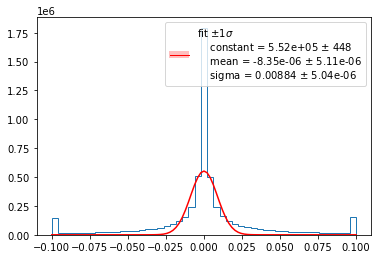

In [15]:
h1 = Hist1D(mva_diff, bins=np.linspace(-0.1,0.1,50))
h1.fit('gaus')
h1.plot()

<AxesSubplot:>

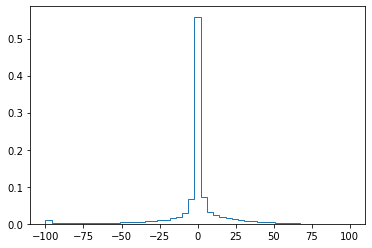

In [21]:
h2= Hist1D(mva_diff_percent, bins=np.linspace(-100,100,50))
h2.plot()

In [25]:
hdf1 = df_1[df_1.mva_score>=0.9]
hdf2 = df_2[df_1.mva_score>=0.9]
h_score_diff = hdf1.mva_score-hdf2.mva_score

<AxesSubplot:>

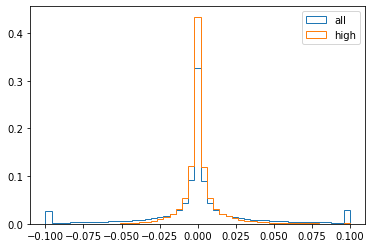

In [30]:
h3 = Hist1D(h_score_diff, bins=np.linspace(-0.1,0.1,50))
h1.normalize().plot(label='all')
h3.normalize().plot(label='high')

In [31]:
len(hdf1.mva_score)/len(df_1.mva_score)

0.5683699230501433

In [33]:
len(df_2.mva_score[df_2.mva_score>=0.9])/len(df_2.mva_score)

0.5680130229294179

In [9]:
def group_mask(df, proc_ids, group):
    tmp_mask = df.process_id==-857 #Not -999 incase some error has occured
    for proc in group:
        tmp_mask = tmp_mask | (df.process_id==proc_ids[proc])
    return tmp_mask

In [13]:
nonres_mask = group_mask(df_1, proc_ids, nonres)
gjets_mask = group_mask(df_1, proc_ids, gjets)
res_mask = group_mask(df_1, proc_ids, res)
signal_mask = group_mask(df_1, proc_ids, signal)
data_mask = df_1.process_id ==proc_ids['Data']
SR1_mask_1 = df_1.mva_score>=0.9925 #SR no stop
SR2_mask_1 = df_1.mva_score>=0.943754 #SR no stop
SR1_mask_2 = df_2.mva_score>=0.9903 #SR sanity
SR2_mask_2 = df_2.mva_score>=0.909545 #SR sanity

In [14]:
full_nonres_mask = nonres_mask | gjets_mask

In [18]:
blind_1 = (df_1.Diphoton_mass < 120) | (df_1.Diphoton_mass > 130)
blind_2 = (df_2.Diphoton_mass < 120) | (df_2.Diphoton_mass > 130)

In [24]:
print(sum(df_1.weight_central[SR1_mask_1 & signal_mask]))
print(sum(df_1.weight_central[SR1_mask_1 & full_nonres_mask]))
print(sum(df_1.weight_central[SR1_mask_1 & res_mask]))

0.05941081759946947
9.375473092838863
3.3359642815455097


In [51]:
gdf = df[gjets_mask & SR1_mask]
nrdf = df[nonres_mask & SR1_mask]
fnrdf = df[full_nonres_mask & SR1_mask]
ddf = df[data_mask & SR1_mask]

In [37]:
def sideband_count(df):
    min_edge = 100
    low_edge = 115
    high_edge = 135
    max_edge = 180
    low_mask = (df.Diphoton_mass >= min_edge) & (df.Diphoton_mass <= low_edge)
    high_mask = (df.Diphoton_mass >= high_edge) & (df.Diphoton_mass <= max_edge)
    low_count = ak.sum(df[low_mask].weight_central)
    high_count = ak.sum(df[high_mask].weight_central)
    print('Num events in the low bin: {}'.format(low_count))
    print('Num events in the high bin: {}'.format(high_count))
    print('----------------------------------')
    print('Num events in the low bin: {:.2f}'.format(low_count))
    print('Num events in the high bin: {:.2f}'.format(high_count))

In [52]:
sideband_count(nrdf)

Num events in the low bin: 1.55424312549341
Num events in the high bin: -1.101810112968988
----------------------------------
Num events in the low bin: 1.55
Num events in the high bin: -1.10


In [53]:
sideband_count(gdf)

Num events in the low bin: 0.0
Num events in the high bin: 0.0
----------------------------------
Num events in the low bin: 0.00
Num events in the high bin: 0.00


In [54]:
sideband_count(fnrdf)

Num events in the low bin: 1.55424312549341
Num events in the high bin: -1.101810112968988
----------------------------------
Num events in the low bin: 1.55
Num events in the high bin: -1.10


In [55]:
sideband_count(ddf)

Num events in the low bin: 4.0
Num events in the high bin: 2.0
----------------------------------
Num events in the low bin: 4.00
Num events in the high bin: 2.00


In [17]:
min_edge = 100
low_edge = 115
high_edge = 135
max_edge = 180
low_mask = (ddf.Diphoton_mass >= min_edge) & (ddf.Diphoton_mass <= low_edge)
high_mask = (ddf.Diphoton_mass >= high_edge) & (ddf.Diphoton_mass <= max_edge)
print(ddf[low_mask].Diphoton_mass)
print(ddf[high_mask].Diphoton_mass)

NameError: name 'ddf' is not defined